**Dependence of HR and HRV**

Using file: rr_hr_all_patients.csv. Containing R peaks, RR intervals and Heart rate (bpm)

In [1]:
import pandas as pd
import numpy as np
import ast

def process_and_modify_hrv(file_path):
    # Load your specific CSV file
    df = pd.read_csv(file_path)
    
    results = []
    
    for index, row in df.iterrows():
        try:
            # 1. Parse the RR intervals (converts the text list into numbers)
            rr_intervals = ast.literal_eval(row['RR_intervals_ms'])
            rr_array = np.array(rr_intervals)
            
            # 2. Calculate baseline HRV (SDNN)
            # we use SDNN as the 'Standard' index
            sdnn = np.std(rr_array)
            
            # 3. Calculate Mean RR interval in ms
            mean_rr = np.mean(rr_array)
            
            # 4. Apply research modifications
            # hrv3: Standard HRV (SDNN) - Predicts all-cause mortality 
            hrv3 = sdnn
            
            # hrv1: Weakened HR Influence - Predicts non-cardiac pathology
            # Formula: HRV / (Mean_RR^4)
            hrv1 = sdnn / (mean_rr**4)
            
            # hrv7: Strengthened HR Influence - Predicts cardiac pathology 
            # Formula: HRV * (Mean_RR^16)
            hrv7 = sdnn * (mean_rr**16)
            
            results.append({
                'Patient_ID': row['Patient_ID'],
                'Avg_HR_bpm': row['Heart_rate_bpm'],
                'Mean_RR_ms': mean_rr,
                'hrv3_Standard': hrv3,
                'hrv1_NonCardiac': hrv1,
                'hrv7_Cardiac': hrv7
            })
        except Exception as e:
            print(f"Error processing Patient {row['Patient_ID']}: {e}")
            continue
            
    return pd.DataFrame(results)

# Run the modification
#df_final = process_and_modify_hrv('rr_hr_all_patients.csv')
#df_final.to_csv('hr_influence_results.csv', index=False)

Plotting results

Cleaning data for plotting... please wait.


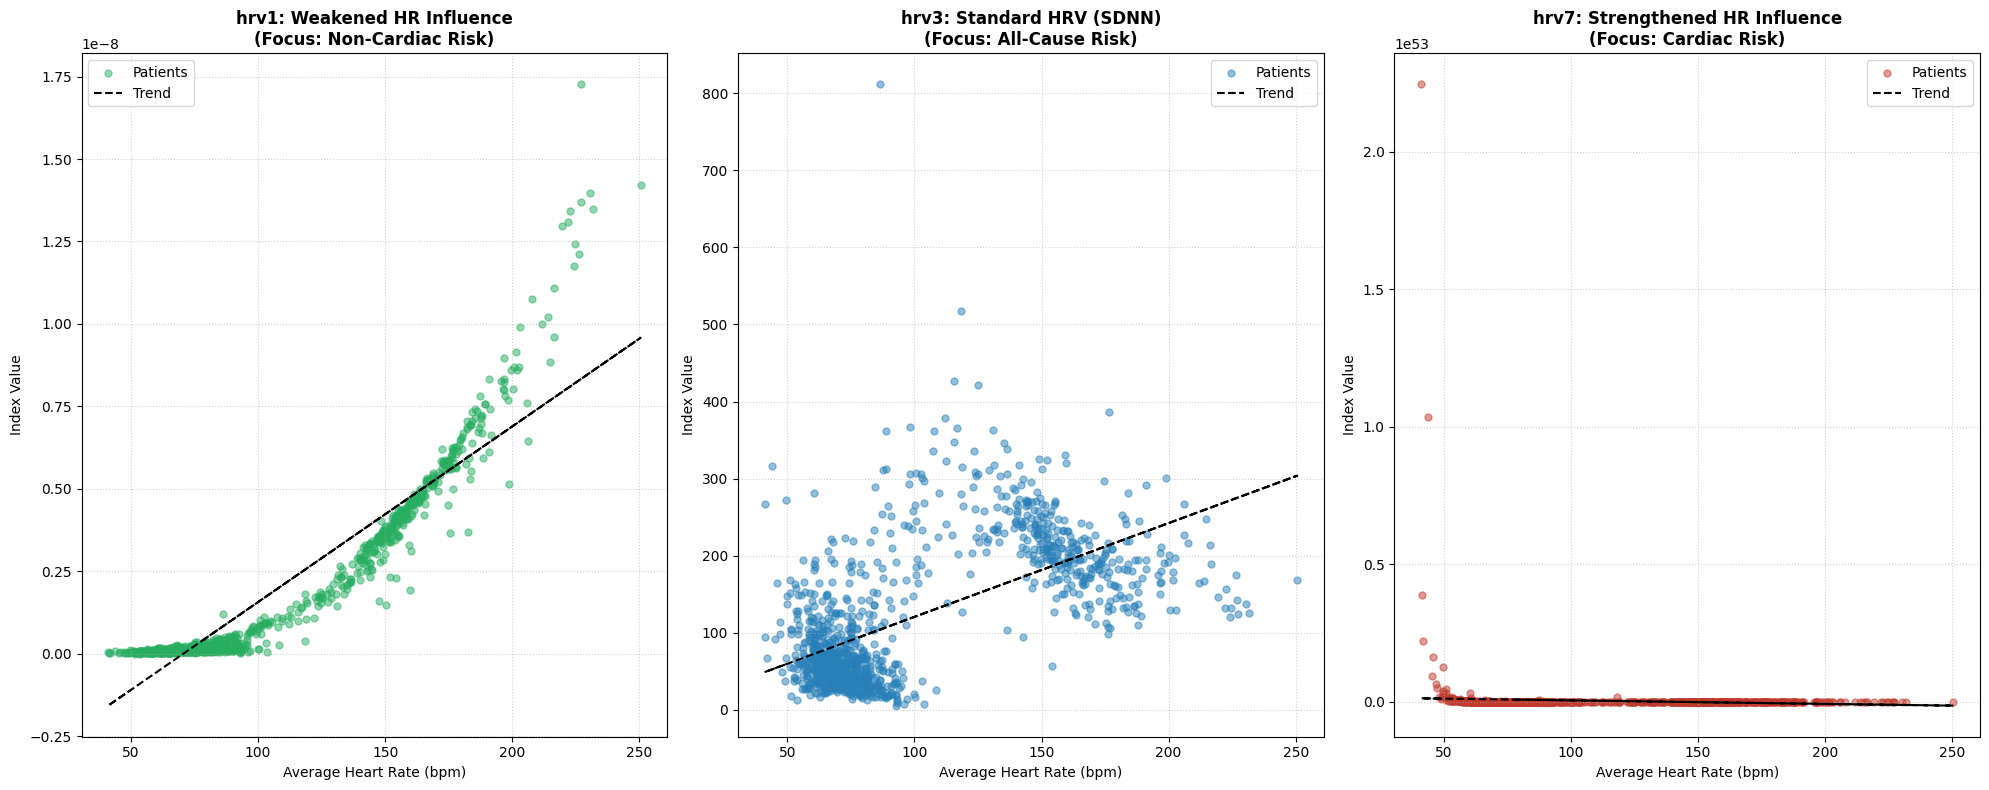

In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

# 1. Load the results
df_results = pd.read_csv('hr_influence_results.csv')

# 2. DATA FIX: Convert HR strings/lists into single numeric averages
def clean_hr_value(val):
    if isinstance(val, str) and '[' in val:
        try:
        
            return np.mean(ast.literal_eval(val))
        except:
            return np.nan
    return float(val)

print("Cleaning data for plotting... please wait.")
df_results['Avg_HR_bpm'] = df_results['Avg_HR_bpm'].apply(clean_hr_value)
df_results = df_results.dropna(subset=['Avg_HR_bpm']) # Remove any rows that failed to convert

# 3. Setup the figure
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

indices = ['hrv1_NonCardiac', 'hrv3_Standard', 'hrv7_Cardiac']
colors = ['#27ae60', '#2980b9', '#c0392b']
titles = [
    'hrv1: Weakened HR Influence\n(Focus: Non-Cardiac Risk)',
    'hrv3: Standard HRV (SDNN)\n(Focus: All-Cause Risk)',
    'hrv7: Strengthened HR Influence\n(Focus: Cardiac Risk)'
]

for i, idx in enumerate(indices):
    x = df_results['Avg_HR_bpm']
    y = df_results[idx]
    
    # Scatter plot
    axes[i].scatter(x, y, alpha=0.5, color=colors[i], s=25, label='Patients')
    
    # Calculate Trend Line
    # Note: hrv7 values are extremely large, so the trend line highlights the massive scale shift
    m, b = np.polyfit(x, y, 1)
    axes[i].plot(x, m*x + b, color='black', linestyle='--', linewidth=1.5, label='Trend')
    
    axes[i].set_title(titles[i], fontweight='bold')
    axes[i].set_xlabel('Average Heart Rate (bpm)')
    axes[i].set_ylabel('Index Value')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()

plt.tight_layout()
plt.show()


Statistical analysis

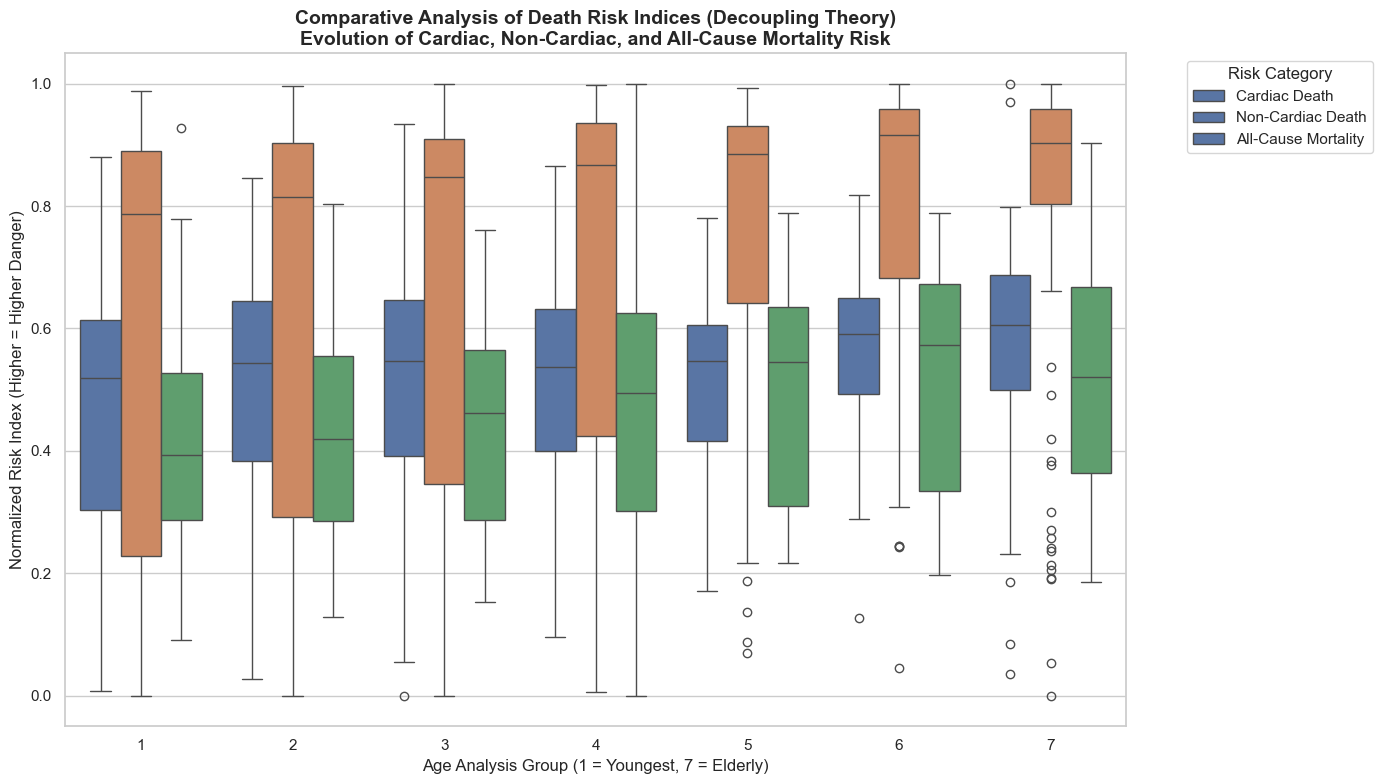

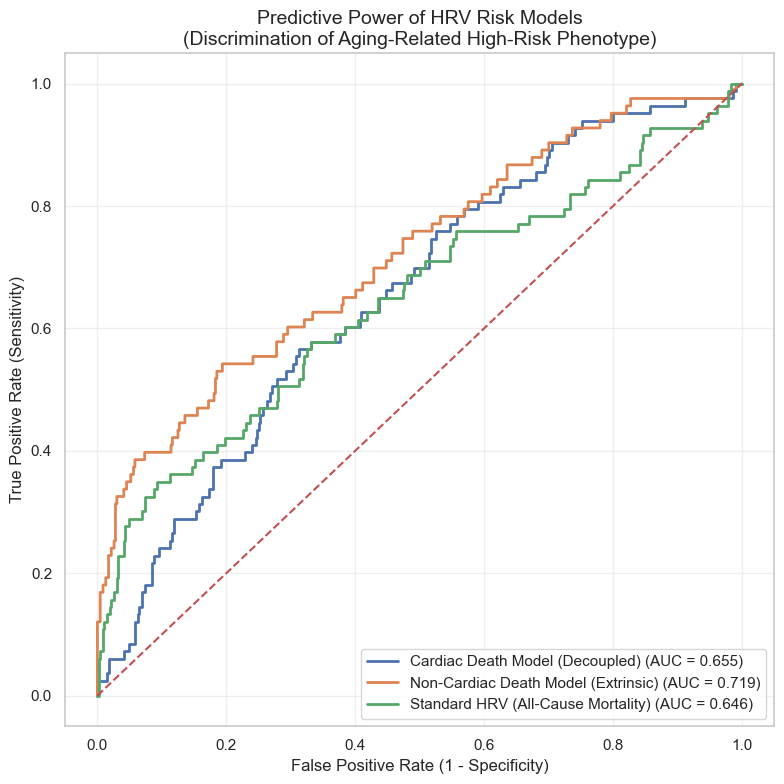


=== SANITY CHECK: Mean Raw Values ===
               Val_Cardiac  Val_NonCardiac  Val_AllCause
HRV_Age_Group                                           
1                47.252767        9.124829     -2.015117
2                47.633500        9.218500     -1.994007
3                47.756118        9.268113     -1.958921
4                47.612479        9.323356     -1.861177
5                47.778681        9.393912     -1.827901
6                48.251889        9.493624     -1.786391
7                48.411070        9.498057     -1.808148

=== SANITY CHECK: Mean Normalized Indices ===
               Index_Cardiac_Death  Index_NonCardiac_Death  \
HRV_Age_Group                                                
1                         0.470798                0.598335   
2                         0.503837                0.646157   
3                         0.514477                0.671485   
4                         0.502013                0.699688   
5                         0.5

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# --- 1. Load and Prepare Data ---
df_hr = pd.read_csv('hr_influence_results.csv')
df_meta = pd.read_csv('analysis_groups.csv')

# Standardize IDs for merging
df_meta['Patient_ID'] = df_meta['ID'].astype(int)
df_total = pd.merge(df_hr, df_meta, on='Patient_ID', how='inner')

# --- 2. Calculate Clinical Risk Indices (Higher = More Risk) ---

epsilon = 1e-10  # numerical stability

# CARDIAC RISK (Intrinsic)
df_total['Val_Cardiac'] = np.log10(df_total['hrv7_Cardiac'] + epsilon)

# NON-CARDIAC RISK (Extrinsic)
Val_NC = -np.log10(df_total['hrv1_NonCardiac'] + epsilon)

# Remove extreme outliers
Val_NC = np.clip(
    Val_NC,
    np.percentile(Val_NC, 1),
    np.percentile(Val_NC, 99)
)

df_total['Val_NonCardiac'] = Val_NC

# ALL-CAUSE MORTALITY RISK (Standard HRV)
df_total['Val_AllCause'] = -np.log10(df_total['hrv3_Standard'] + epsilon)

# --- 3. Normalization (0 to 1 Scale) ---
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

df_total['Index_Cardiac_Death'] = normalize(df_total['Val_Cardiac'])
df_total['Index_NonCardiac_Death'] = normalize(df_total['Val_NonCardiac'])
df_total['Index_AllCause_Mortality'] = normalize(df_total['Val_AllCause'])

# --- 4. VISUAL 1: Pathology Evolution Across Age Groups ---
df_melt = df_total.melt(
    id_vars=['HRV_Age_Group'],
    value_vars=[
        'Index_Cardiac_Death',
        'Index_NonCardiac_Death',
        'Index_AllCause_Mortality'
    ],
    var_name='Risk_Type',
    value_name='Risk_Level'
)

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_melt,
    x='HRV_Age_Group',
    y='Risk_Level',
    hue='Risk_Type'
)

plt.title(
    "Comparative Analysis of Death Risk Indices (Decoupling Theory)\n"
    "Evolution of Cardiac, Non-Cardiac, and All-Cause Mortality Risk",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Normalized Risk Index (Higher = Higher Danger)")
plt.xlabel("Age Analysis Group (1 = Youngest, 7 = Elderly)")

plt.legend(
    title='Risk Category',
    labels=[
        'Cardiac Death',
        'Non-Cardiac Death',
        'All-Cause Mortality'
    ],
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# --- 5. VISUAL 2: Prediction Power (ROC/AUC Analysis) ---
df_roc = df_total[df_total['HRV_Age_Group'].isin([1, 7])].copy()
df_roc['Target'] = (df_roc['HRV_Age_Group'] == 7).astype(int)

plt.figure(figsize=(8, 8))

models = [
    ('Index_Cardiac_Death', 'Cardiac Death Model (Decoupled)'),
    ('Index_NonCardiac_Death', 'Non-Cardiac Death Model (Extrinsic)'),
    ('Index_AllCause_Mortality', 'Standard HRV (All-Cause Mortality)')
]

for col, label in models:
    fpr, tpr, _ = roc_curve(df_roc['Target'], df_roc[col])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{label} (AUC = {roc_auc:.3f})'
    )

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title(
    'Predictive Power of HRV Risk Models\n'
    '(Discrimination of Aging-Related High-Risk Phenotype)',
    fontsize=14
)

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- 6. SANITY CHECKS ---
print("\n=== SANITY CHECK: Mean Raw Values ===")
print(df_total.groupby('HRV_Age_Group')[[
    'Val_Cardiac',
    'Val_NonCardiac',
    'Val_AllCause'
]].mean())

print("\n=== SANITY CHECK: Mean Normalized Indices ===")
print(df_total.groupby('HRV_Age_Group')[[
    'Index_Cardiac_Death',
    'Index_NonCardiac_Death',
    'Index_AllCause_Mortality'
]].mean())

print("\n=== DISTRIBUTION CHECK ===")
print(df_total[[
    'Val_Cardiac',
    'Val_NonCardiac',
    'Val_AllCause'
]].describe())

print("\nFull Pathology Analysis Successfully Completed.")